In [56]:
import matplotlib.pyplot as plt
import sys

import awkward as ak

import uproot

In [2]:
x_sections = {
                'QCD_PT-120to170': 445800.0,
                'QCD_PT-170to300': 113700.0,
                'QCD_PT-300to470': 7589.0,
                'QCD_PT-470to600': 626.4,
                'QCD_PT-600to800': 178.6,
                'QCD_PT-800to1000': 30.57,
                'QCD_PT-1000to1400': 8.92,
                'QCD_PT-1400to1800': 0.8103,
                'QCD_PT-1800to2400': 0.1148,
                'QCD_PT-2400to3200': 0.007542,
                'QCD_PT-3200': 0.0002331
}

 

def QCD_sample_name(name):
    for key in x_sections.keys():
        if key in name:
            return key
    return None

In [3]:
files = []
with open("Run3/qcd_files.txt",'r') as file_list:
    for line in file_list:
        line = line.strip()
        files.append("Run3/mc/QCD/" + line)

In [9]:
qcd_mc = {}

for file in files:
    print("Processing " + file + "...")
    name = QCD_sample_name(file)
    if name is None:
        continue
    f = uproot.open(file)
    br = f['events'].arrays()

    events = f['cut_flow_hist'].values()[0]
    qcd_mc[name] = {"data": f['events'].arrays(), "weight": [x_sections[name] / events]* len(br['event_HT'])}
    #HT.append([br['event_HT'], [x_sections[name] / events]* len(br['event_HT']),name])
    #highest_PT_jet.append([br['ak4_pt'][:,0], [x_sections[name] / events]* len(br['ak4_pt'][:,0]),name])

Processing Run3/mc/QCD/slimmedNtup_QCD_PT-170to300_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-300to470_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-470to600_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-600to800_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-800to1000_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1000to1400_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1400to1800_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-1800to2400_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-2400to3200_TuneCP5_13p6TeV_pythia8_nanogen.root...
Processing Run3/mc/QCD/slimmedNtup_QCD_PT-3200_TuneCP5_13p6TeV_pythia8_nanogen.root...


In [11]:
[val["data"]["event_HT"] for val in qcd_mc.values()]

[<Array [1.23e+03, 1.28e+03, 1.16e+03, ..., 651, 1.06e+03] type='1566 * float32'>,
 <Array [1.14e+03, 1.34e+03, ..., 1.56e+03, 1.23e+03] type='11433 * float32'>,
 <Array [1.45e+03, 1.74e+03, ..., 1.42e+03, 1.03e+03] type='26267 * float32'>,
 <Array [1.84e+03, 1.37e+03, ..., 1.64e+03, 1.53e+03] type='59559 * float32'>,
 <Array [2.73e+03, 2.23e+03, ..., 1.83e+03, 1.89e+03] type='36210 * float32'>,
 <Array [2.75e+03, 2.45e+03, ..., 2.03e+03, 2.71e+03] type='15065 * float32'>,
 <Array [2.86e+03, 3.44e+03, ..., 3.1e+03, 3.16e+03] type='18273 * float32'>,
 <Array [4.04e+03, 4.88e+03, ..., 4.04e+03, 3.79e+03] type='11807 * float32'>,
 <Array [5.38e+03, 5.11e+03, ..., 3.94e+03, 5.85e+03] type='5188 * float32'>,
 <Array [6.88e+03, 7.08e+03, ..., 6.68e+03, 6.78e+03] type='549 * float32'>]

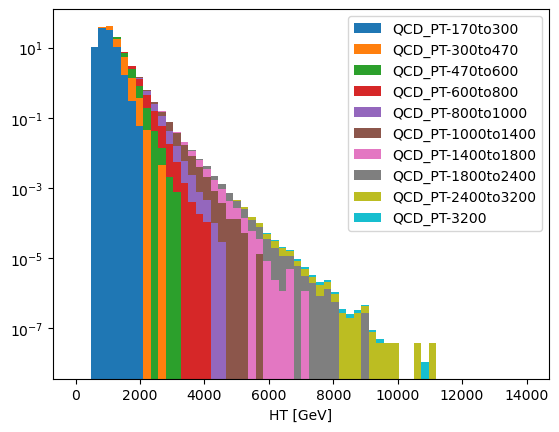

In [41]:
plt.hist(
    [val["data"]["event_HT"] for val in qcd_mc.values()], 
    weights= [val["weight"] for val in qcd_mc.values()], 
    bins= 60,
    stacked=True,
    label=[key for key in qcd_mc.keys()],
    range=(0,14000))

plt.xlabel("HT [GeV]")
#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')

plt.legend()

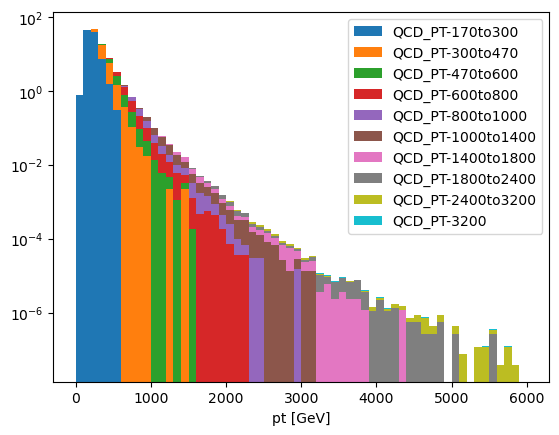

In [44]:
plt.hist(
    [val["data"]['ak4_pt'][:,0] for val in qcd_mc.values()],
    weights= [val["weight"] for val in qcd_mc.values()], 
    bins= 60,
    stacked=True,
    label=[key for key in qcd_mc.keys()],
    range=(0,6000)
    )
plt.xlabel("pt [GeV]")

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')
plt.legend()

In [76]:

masked_data = {}
# event_HT>550 && sixpt>40 && jmds6332<1.25 && jtrip_masym <0.25 && jtrip_delta>250 && jtrip_mds<0.05
for val,key in zip(qcd_mc.values(),qcd_mc.keys()):
    mask  = val["data"].mask[val["data"].event_HT > 1000].mask[val["data"].sixpt > 40].mask[val["data"].jmds6332<1.25].mask[val["data"].jtrip_masym <0.25].mask[val["data"].jtrip_delta>250].mask[val["data"].jtrip_mds<0.05]
    masked_data[key] = {"jtrip_mass": ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))), "weight": [val["weight"][0]]*len(ak.flatten(ak.flatten(ak.drop_none(mask.jtrip_mass))))}

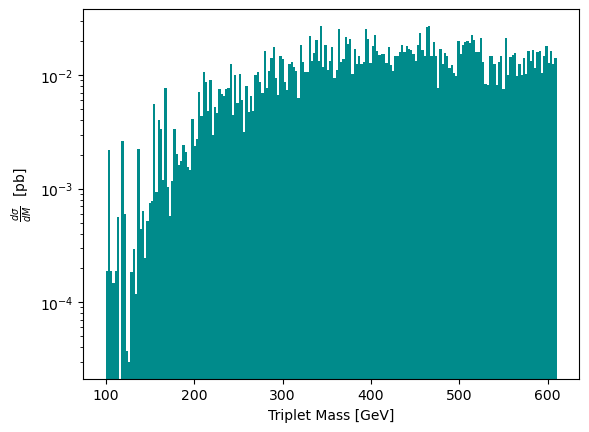

In [108]:
plt.hist(
    [val["jtrip_mass"] for val in masked_data.values()],
    weights= [val["weight"] for val in masked_data.values()], 
    bins= 200,
    stacked=True,
    histtype='stepfilled',
    color=["darkcyan"]*10,
    label=[key for key in masked_data.keys()],
    range=(100,610)
    )
plt.xlabel("Triplet Mass [GeV]")
plt.ylabel(r"$\frac{d\sigma}{dM}$  [pb]")

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')